In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/customer_data.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (20, 13)


,CustomerID,Age,Gender,AnnualIncome,TotalSpending,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,ProductCategory,PurchaseLikelihood
0,C001,25,Male,350000,45000,12,3750,5,25,10,4.5,Electronics,1
1,C002,32,Female,500000,75000,20,3750,10,35,15,4.8,Fashion,1
2,C003,45,Male,700000,25000,5,5000,90,8,40,3.5,Home,0
3,C004,29,Female,420000,30000,8,3750,20,15,20,4.0,Fashion,1
4,C005,52,Male,900000,120000,30,4000,3,40,5,4.9,Electronics,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             20 non-null     object 
 1   Age                    20 non-null     int64  
 2   Gender                 20 non-null     object 
 3   AnnualIncome           20 non-null     int64  
 4   TotalSpending          20 non-null     int64  
 5   PurchaseFrequency      20 non-null     int64  
 6   AverageOrderValue      20 non-null     int64  
 7   DaysSinceLastPurchase  20 non-null     int64  
 8   WebsiteVisits          20 non-null     int64  
 9   DiscountUsage          20 non-null     int64  
 10  CustomerRating         20 non-null     float64
 11  ProductCategory        20 non-null     object 
 12  PurchaseLikelihood     20 non-null     int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 2.2+ KB


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
CustomerID               0
Age                      0
Gender                   0
AnnualIncome             0
TotalSpending            0
PurchaseFrequency        0
AverageOrderValue        0
DaysSinceLastPurchase    0
WebsiteVisits            0
DiscountUsage            0
CustomerRating           0
ProductCategory          0
PurchaseLikelihood       0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


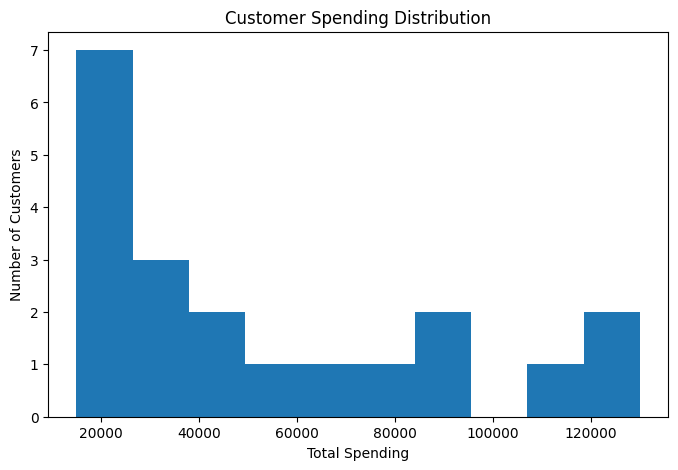

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df["TotalSpending"], bins=10)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

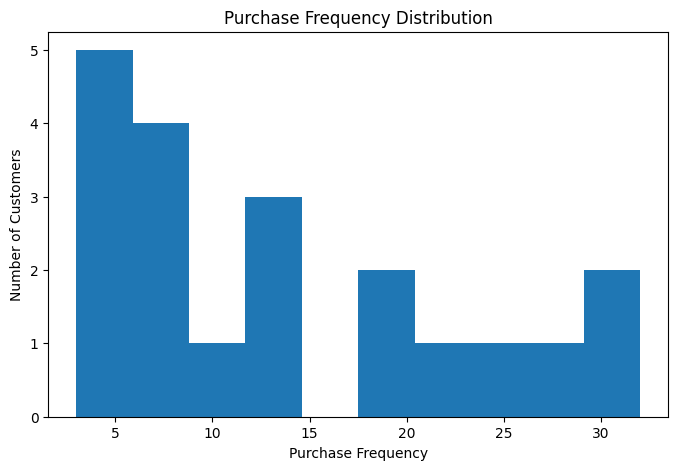

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["PurchaseFrequency"], bins=10)

plt.title("Purchase Frequency Distribution")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
rfm = df[
    [
        "CustomerID",
        "DaysSinceLastPurchase",
        "PurchaseFrequency",
        "TotalSpending"
    ]
].copy()

rfm.rename(
    columns={
        "DaysSinceLastPurchase": "Recency",
        "PurchaseFrequency": "Frequency",
        "TotalSpending": "Monetary"
    },
    inplace=True
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,C001,5,12,45000
1,C002,10,20,75000
2,C003,90,5,25000
3,C004,20,8,30000
4,C005,3,30,120000


In [9]:
rfm_features = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

scaler = StandardScaler()

scaled_rfm = scaler.fit_transform(rfm_features)

print("RFM values scaled successfully")

RFM values scaled successfully


In [10]:
inertia = []
silhouette_scores = []

k_values = range(2, 7)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_rfm)

    inertia.append(model.inertia_)

    silhouette_scores.append(
        silhouette_score(scaled_rfm, labels)
    )

print("K values tested successfully")

K values tested successfully


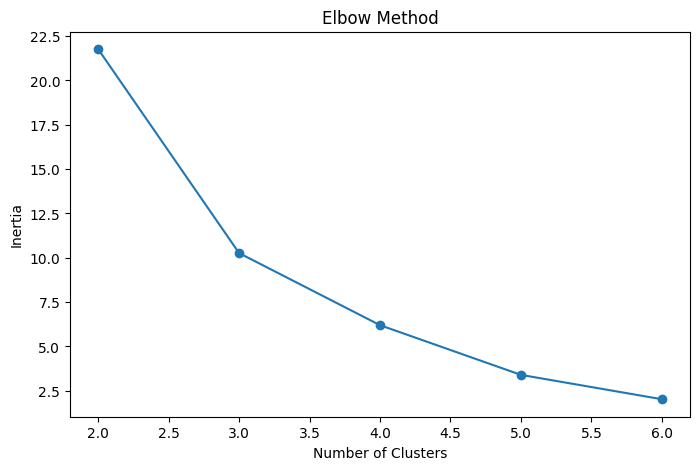

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

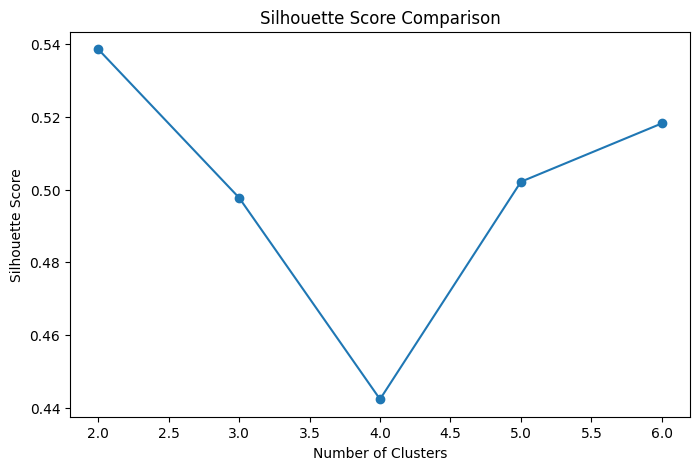

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [13]:
final_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = final_model.fit_predict(scaled_rfm)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,C001,5,12,45000,0
1,C002,10,20,75000,0
2,C003,90,5,25000,1
3,C004,20,8,30000,3
4,C005,3,30,120000,2


In [14]:
df["Cluster"] = rfm["Cluster"]

df.head()

,CustomerID,Age,Gender,AnnualIncome,TotalSpending,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,ProductCategory,PurchaseLikelihood,Cluster
0,C001,25,Male,350000,45000,12,3750,5,25,10,4.5,Electronics,1,0
1,C002,32,Female,500000,75000,20,3750,10,35,15,4.8,Fashion,1,0
2,C003,45,Male,700000,25000,5,5000,90,8,40,3.5,Home,0,1
3,C004,29,Female,420000,30000,8,3750,20,15,20,4.0,Fashion,1,3
4,C005,52,Male,900000,120000,30,4000,3,40,5,4.9,Electronics,1,2


In [15]:
cluster_profile = df.groupby("Cluster").agg(
    CustomerCount=("CustomerID", "count"),
    AverageSpending=("TotalSpending", "mean"),
    AverageFrequency=("PurchaseFrequency", "mean"),
    AverageRecency=("DaysSinceLastPurchase", "mean"),
    AverageOrderValue=("AverageOrderValue", "mean"),
    AverageRating=("CustomerRating", "mean"),
    AverageDiscountUsage=("DiscountUsage", "mean")
)

cluster_profile

,CustomerCount,AverageSpending,AverageFrequency,AverageRecency,AverageOrderValue,AverageRating,AverageDiscountUsage
Cluster,,,,,,,
0,5,57400.000000,15.400000,10.600000,3721.200000,4.520000,14.200000
1,3,19666.666667,4.000000,120.000000,4944.333333,3.233333,48.333333
2,5,108000.000000,27.200000,4.400000,3962.200000,4.840000,6.600000
3,7,24000.000000,6.571429,41.428571,3654.857143,3.871429,30.714286


In [16]:
df.to_csv(
    "../reports/customer_segments.csv",
    index=False
)

cluster_profile.to_csv(
    "../reports/cluster_profile.csv"
)

print("Files saved successfully")

Files saved successfully


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Model libraries imported successfully")

Model libraries imported successfully


In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Model libraries imported successfully")

Model libraries imported successfully


In [23]:
regression_features = [
    "Age",
    "AnnualIncome",
    "PurchaseFrequency",
    "AverageOrderValue",
    "DaysSinceLastPurchase",
    "WebsiteVisits",
    "DiscountUsage",
    "CustomerRating"
]

X_reg = df[regression_features]
y_reg = df["TotalSpending"]

print(X_reg.head())

   Age  AnnualIncome  PurchaseFrequency  AverageOrderValue  \
0   25        350000                 12               3750   
1   32        500000                 20               3750   
2   45        700000                  5               5000   
3   29        420000                  8               3750   
4   52        900000                 30               4000   

   DaysSinceLastPurchase  WebsiteVisits  DiscountUsage  CustomerRating  
0                      5             25             10             4.5  
1                     10             35             15             4.8  
2                     90              8             40             3.5  
3                     20             15             20             4.0  
4                      3             40              5             4.9  


In [24]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

print("Regression training data:", X_reg_train.shape)
print("Regression testing data:", X_reg_test.shape)

Regression training data: (15, 8)
Regression testing data: (5, 8)


In [25]:
reg_scaler = StandardScaler()

X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train)
X_reg_test_scaled = reg_scaler.transform(X_reg_test)

print("Regression data scaled successfully")

Regression data scaled successfully


In [26]:
linear_model = LinearRegression()

linear_model.fit(X_reg_train_scaled, y_reg_train)

linear_predictions = linear_model.predict(X_reg_test_scaled)

print("R² Score:", r2_score(y_reg_test, linear_predictions))

R² Score: 0.9891547202383556


In [27]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_reg_train_scaled,
    y_reg_train
)

ridge_predictions = ridge_model.predict(
    X_reg_test_scaled
)

ridge_mae = mean_absolute_error(
    y_reg_test,
    ridge_predictions
)

ridge_mse = mean_squared_error(
    y_reg_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(
    y_reg_test,
    ridge_predictions
)

print("Ridge Regression Results")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Results
MAE: 2276.6754241357166
MSE: 8824785.561768895
RMSE: 2970.6540629580036
R2 Score: 0.9715915994019801


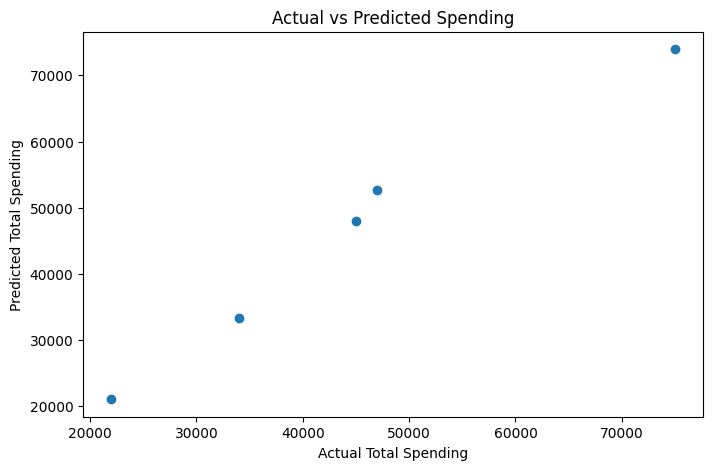

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_reg_test,
    ridge_predictions
)

plt.xlabel("Actual Total Spending")
plt.ylabel("Predicted Total Spending")
plt.title("Actual vs Predicted Spending")

plt.show()

In [29]:
ridge_parameters = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_parameters,
    cv=3,
    scoring="r2"
)

ridge_grid.fit(
    X_reg_train_scaled,
    y_reg_train
)

best_ridge_model = ridge_grid.best_estimator_

best_ridge_predictions = best_ridge_model.predict(
    X_reg_test_scaled
)

tuned_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        best_ridge_predictions
    )
)

tuned_ridge_r2 = r2_score(
    y_reg_test,
    best_ridge_predictions
)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Tuned Ridge RMSE:", tuned_ridge_rmse)
print("Tuned Ridge R2:", tuned_ridge_r2)

Best Ridge parameters: {'alpha': 0.01}
Tuned Ridge RMSE: 1120.3552026537586
Tuned Ridge R2: 0.9959593233964932


In [30]:
classification_features = [
    "Age",
    "AnnualIncome",
    "TotalSpending",
    "PurchaseFrequency",
    "AverageOrderValue",
    "DaysSinceLastPurchase",
    "WebsiteVisits",
    "DiscountUsage",
    "CustomerRating",
    "Cluster"
]

X_clf = df[classification_features]
y_clf = df["PurchaseLikelihood"]

print(X_clf.head())
print(y_clf.head())

   Age  AnnualIncome  TotalSpending  PurchaseFrequency  AverageOrderValue  \
0   25        350000          45000                 12               3750   
1   32        500000          75000                 20               3750   
2   45        700000          25000                  5               5000   
3   29        420000          30000                  8               3750   
4   52        900000         120000                 30               4000   

   DaysSinceLastPurchase  WebsiteVisits  DiscountUsage  CustomerRating  \
0                      5             25             10             4.5   
1                     10             35             15             4.8   
2                     90              8             40             3.5   
3                     20             15             20             4.0   
4                      3             40              5             4.9   

   Cluster  
0        0  
1        0  
2        1  
3        3  
4        2  
0    1
1    1


In [31]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_clf
)

print("Classification training data:", X_clf_train.shape)
print("Classification testing data:", X_clf_test.shape)

Classification training data: (15, 10)
Classification testing data: (5, 10)


In [32]:
clf_scaler = StandardScaler()

X_clf_train_scaled = clf_scaler.fit_transform(
    X_clf_train
)

X_clf_test_scaled = clf_scaler.transform(
    X_clf_test
)

print("Classification data scaled successfully")

Classification data scaled successfully


In [33]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_clf_train_scaled,
    y_clf_train
)

classification_predictions = logistic_model.predict(
    X_clf_test_scaled
)

classification_probabilities = logistic_model.predict_proba(
    X_clf_test_scaled
)[:, 1]

clf_accuracy = accuracy_score(
    y_clf_test,
    classification_predictions
)

clf_precision = precision_score(
    y_clf_test,
    classification_predictions,
    zero_division=0
)

clf_recall = recall_score(
    y_clf_test,
    classification_predictions,
    zero_division=0
)

clf_f1 = f1_score(
    y_clf_test,
    classification_predictions,
    zero_division=0
)

clf_roc_auc = roc_auc_score(
    y_clf_test,
    classification_probabilities
)

print("Logistic Regression Results")
print("Accuracy:", clf_accuracy)
print("Precision:", clf_precision)
print("Recall:", clf_recall)
print("F1 Score:", clf_f1)
print("ROC-AUC Score:", clf_roc_auc)

Logistic Regression Results
Accuracy: 0.8
Precision: 0.75
Recall: 1.0
F1 Score: 0.8571428571428571
ROC-AUC Score: 1.0


In [34]:
print(
    classification_report(
        y_clf_test,
        classification_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



In [37]:
conf_matrix = confusion_matrix(
    y_clf_test,
    classification_predictions
)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[1 1]
 [0 3]]


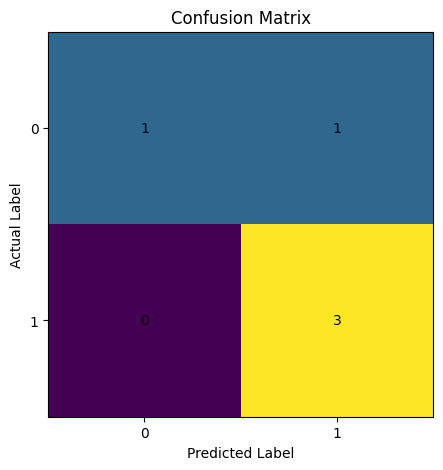

In [38]:
plt.figure(figsize=(6, 5))

plt.imshow(conf_matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.show()

In [39]:
logistic_parameters = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [1000]
}

logistic_grid = GridSearchCV(
    LogisticRegression(),
    logistic_parameters,
    cv=3,
    scoring="f1"
)

logistic_grid.fit(
    X_clf_train_scaled,
    y_clf_train
)

best_logistic_model = logistic_grid.best_estimator_

tuned_clf_predictions = best_logistic_model.predict(
    X_clf_test_scaled
)

tuned_clf_probabilities = best_logistic_model.predict_proba(
    X_clf_test_scaled
)[:, 1]

tuned_clf_f1 = f1_score(
    y_clf_test,
    tuned_clf_predictions,
    zero_division=0
)

tuned_clf_roc_auc = roc_auc_score(
    y_clf_test,
    tuned_clf_probabilities
)

print("Best Logistic parameters:", logistic_grid.best_params_)
print("Tuned F1 Score:", tuned_clf_f1)
print("Tuned ROC-AUC Score:", tuned_clf_roc_auc)

Best Logistic parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
Tuned F1 Score: 0.75
Tuned ROC-AUC Score: 1.0


In [43]:
linear_model = LinearRegression()

linear_model.fit(X_reg_train_scaled, y_reg_train)

linear_predictions = linear_model.predict(X_reg_test_scaled)

linear_mae = mean_absolute_error(y_reg_test, linear_predictions)
linear_mse = mean_squared_error(y_reg_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_reg_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MAE: 1433.9673439972496
RMSE: 1835.4775142063752
R2 Score: 0.9891547202383556


In [44]:
model_comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression"
    ],
    "Objective": [
        "Customer Segmentation",
        "Predict Total Spending",
        "Predict Total Spending",
        "Predict Purchase Likelihood"
    ],
    "Baseline Performance": [
        max(silhouette_scores),
        linear_r2,
        ridge_r2,
        clf_f1
    ],
    "Tuned Performance": [
        max(silhouette_scores),
        linear_r2,
        tuned_ridge_r2,
        tuned_clf_f1
    ]
})

print(model_comparison)

                 Model                    Objective  Baseline Performance  \
0              K-Means        Customer Segmentation              0.538581   
1    Linear Regression       Predict Total Spending              0.989155   
2     Ridge Regression       Predict Total Spending              0.971592   
3  Logistic Regression  Predict Purchase Likelihood              0.857143   

   Tuned Performance  
0           0.538581  
1           0.989155  
2           0.995959  
3           0.750000  


In [45]:
model_comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully")

Model comparison saved successfully
